In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")

## All Calls - Direct

In [ ]:
df1 = pd.read_excel('January 2025.xlsx', dtype=str, keep_default_na=False)
df2= pd.read_excel('February 2025.xlsx', dtype=str, keep_default_na=False)
df3= pd.read_excel('March 2025.xlsx', dtype=str, keep_default_na=False)

In [3]:
df4= pd.read_excel('April 2024.xlsx', dtype=str, keep_default_na=False)
df5= pd.read_excel('May 2024.xlsx', dtype=str, keep_default_na=False)
df6= pd.read_excel('June 2024.xlsx', dtype=str, keep_default_na=False)

In [4]:
df7= pd.read_excel('July 2024.xlsx', dtype=str, keep_default_na=False)
df8= pd.read_excel('August 2024.xlsx', dtype=str, keep_default_na=False)
df9= pd.read_excel('September 2024.xlsx', dtype=str, keep_default_na=False)

In [5]:
df10= pd.read_excel('October 2024.xlsx', dtype=str, keep_default_na=False)
df11= pd.read_excel('November 2024 corrected.xlsx', dtype=str, keep_default_na=False)
df12= pd.read_excel('December 2024.xlsx', dtype=str, keep_default_na=False)

In [6]:
dfs = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12]
full_year_df = pd.concat(dfs, ignore_index=True)

numbers_names = {
    '13122296071': 'Criminal Records',
    '13123478309': 'HIV Intake VM',
    '13124235938': 'legalclinics',
    '13123478340': 'Veterans Rights Project VM',
    '13122296073': 'Trafficking Survivors Assistance Project'
}

In [7]:
full_year_df['Called number'] = full_year_df['Called number'].astype(str)


In [8]:
hiv_calls = full_year_df[full_year_df['Called number'] == '13123478309']
cr_calls= full_year_df[full_year_df['Called number'] == '13122296071']
clinics_calls= full_year_df[full_year_df['Called number'] == '13124235938']
veterans_calls= full_year_df[full_year_df['Called number'] == '13123478340']
trafficking_calls= full_year_df[full_year_df['Called number'] == '13122296073']

In [9]:
hiv_calls['Correlation ID'].nunique()

741

In [10]:
cr_calls['Correlation ID'].nunique()

3195

In [11]:
clinics_calls['Correlation ID'].nunique()

20000

In [13]:
veterans_calls['Correlation ID'].nunique()

1757

In [14]:
trafficking_calls['Correlation ID'].nunique()

102

In [61]:
other_calls= full_year_df[full_year_df['Called number'] == '13122296344'] # used to find total number of calls for other intake lines
other_calls['Correlation ID'].nunique()

4503

## CAR - Transfers

In [4]:
jan_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25).xlsx')
jan_3_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25).xlsx')
feb_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25).xlsx')
feb_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25).xlsx')
mar_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25).xlsx')
apr_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24).xlsx')
apr_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24).xlsx')
may_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24).xlsx')
may_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24).xlsx')
jun_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24).xlsx')
jun_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24).xlsx')
jul_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24).xlsx')
jul_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (07-14-24 - 07-27-24).xlsx')
aug_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (07-28-24 - 08-10-24).xlsx')
aug_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (08-11-24 - 08-24-24).xlsx')
sep_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (08-24-24 - 09-07-24).xlsx')
sep_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (09-08-24 - 09-21-24).xlsx')
sep_3_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (09-22-24 - 10-05-24).xlsx')
oct_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (10-06-24 - 10-19-24).xlsx')
oct_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (10-20-24 - 11-02-24).xlsx')
nov_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (11-03-24 - 11-16-24).xlsx')
nov_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (11-17-24 - 11-30-24).xlsx')
dec_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (12-01-24 - 12-14-24).xlsx')
dec_2_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (12-15-24 - 12-28-24).xlsx')
jan_1_activities = pd.read_excel('CAR - EP, Flow, Activity, Queue, & Agent Names (12-29-24 - 01-11-25).xlsx')

In [5]:
def car_cleaning(df):
    df.rename(columns = {'Time Zone: (UTC-05:00) Central Daylight Time (America/Chicago)': 'Contact Session ID',
                         'Unnamed: 1': 'EP Name',
                         'Unnamed: 2': 'Flow Name',
                         'Unnamed: 3': 'Activity Name',
                         'Unnamed: 4': 'Activity Start Timestamp',
                         'Unnamed: 5': 'Queue Name',
                         'Unnamed: 6': 'Agent Name'}, inplace = True)
    df = df.iloc[2:]
    df.reset_index(inplace = True, drop = True)
    return df

In [6]:
car_data = [jan_1_activities, jan_2_activities, jan_3_activities, feb_1_activities, feb_2_activities,
                     mar_1_activities, apr_1_activities, apr_2_activities, may_1_activities, may_2_activities,
                     jun_1_activities, jun_2_activities, jul_1_activities, jul_2_activities, aug_1_activities,
                     aug_2_activities, sep_1_activities, sep_2_activities, sep_3_activities, oct_1_activities, oct_2_activities,
                     nov_1_activities, nov_2_activities, dec_1_activities, dec_2_activities]

for i in range(len(car_data)):
    car_data[i] = car_cleaning(car_data[i])

(jan_1_activities, jan_2_activities, jan_3_activities, feb_1_activities, feb_2_activities,
                     mar_1_activities, apr_1_activities, apr_2_activities, may_1_activities, may_2_activities,
                     jun_1_activities, jun_2_activities, jul_1_activities, jul_2_activities, aug_1_activities,
                     aug_2_activities, sep_1_activities, sep_2_activities, sep_3_activities, oct_1_activities, oct_2_activities,
                     nov_1_activities, nov_2_activities, dec_1_activities, dec_2_activities) = car_data

In [7]:
all_car_data = pd.concat([jan_1_activities, jan_2_activities, jan_3_activities, feb_1_activities, feb_2_activities,
                     mar_1_activities, apr_1_activities, apr_2_activities, may_1_activities, may_2_activities,
                     jun_1_activities, jun_2_activities, jul_1_activities, jul_2_activities, aug_1_activities,
                     aug_2_activities, sep_1_activities, sep_3_activities, oct_1_activities, oct_2_activities,
                     nov_1_activities, nov_2_activities, dec_1_activities, dec_2_activities])

all_car_data.drop_duplicates(inplace= True)

In [19]:
subset1 = all_car_data[all_car_data['Activity Name'].str.contains('Criminal', na=False)]
result1 = subset1.groupby(['EP Name', 'Activity Name'])['Contact Session ID'].apply(lambda x: len(x.unique()))
result1

EP Name                        Activity Name                   
Legal Menu Telephony EP        CriminalRecordsVoicemailTransfer    1412
Other Legal Menu Telephony EP  OtherLegalCriminalCaseMenu          1292
Name: Contact Session ID, dtype: int64

In [20]:
subset2 = all_car_data[all_car_data['Activity Name'].str.contains('HIV', na=False)]
result2 = subset2.groupby(['EP Name', 'Activity Name'])['Contact Session ID'].apply(lambda x: len(x.unique()))
result2

EP Name                      Activity Name       
Legal HIV Menu Telephony EP  HIVMenu                 1280
                             HIVVoicemailTransfer     536
Name: Contact Session ID, dtype: int64

In [21]:
subset3 = all_car_data[all_car_data['Activity Name'].str.contains('Clinic', na=False)]
result3 = subset3.groupby(['EP Name', 'Activity Name'])['Contact Session ID'].apply(lambda x: len(x.unique()))
result3

EP Name                                  Activity Name          
Closed Hours-Holidays Menu Telephony EP  ClinicVoicemailTransfer     826
Closed Queue Menu Telephony EP           ClinicVoicemailTransfer    4898
Legal Family Menu Telephony EP           ClinicVoicemailTransfer     268
Legal Housing Menu Telephony EP          ClinicVoicemailTransfer     454
Main Number Telephony EP                 ClinicVoicemailTransfer    7903
Other Legal Menu Telephony EP            ClinicVoicemailTransfer    1418
Name: Contact Session ID, dtype: int64

In [24]:
result3.sum()

15767

In [22]:
subset4 = all_car_data[all_car_data['Activity Name'].str.contains('Veteran', na=False)]
result4 = subset4.groupby(['EP Name', 'Activity Name'])['Contact Session ID'].apply(lambda x: len(x.unique()))
result4

EP Name                           Activity Name                    
Legal Benefits Menu Telephony EP  VeteransBenefitsVoicemailTransfer    116
Name: Contact Session ID, dtype: int64

In [23]:
subset5 = all_car_data[all_car_data['Activity Name'].str.contains('Traffic', na=False)]
result5 = subset5.groupby(['EP Name', 'Activity Name'])['Contact Session ID'].apply(lambda x: len(x.unique()))
result5

EP Name                              Activity Name               
Legal Immigration Menu Telephony EP  TraffickingVoicemailTransfer    93
Name: Contact Session ID, dtype: int64

                                   Category  Transfer Call %  Direct Call %
0                          Criminal Records        30.649012      69.350988
1                             HIV Intake VM        41.973375      58.026625
2                              legalclinics        44.082534      55.917466
3                Veterans Rights Project VM         6.193273      93.806727
4  Trafficking Survivors Assistance Project        47.692308      52.307692


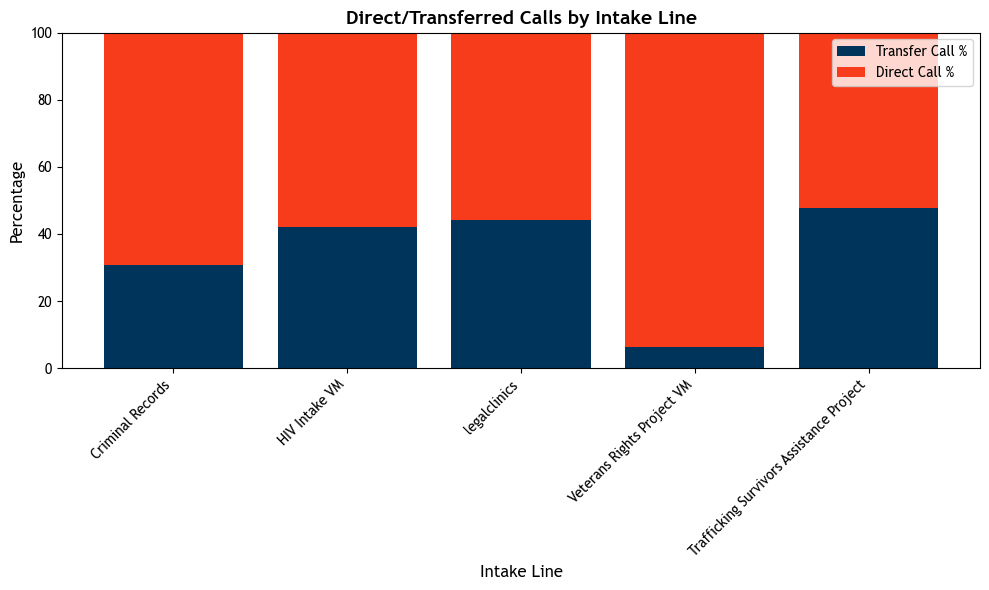

In [41]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Trebuchet MS'

category_labels = ['Criminal Records', 'HIV Intake VM', 'legalclinics', 'Veterans Rights Project VM', 'Trafficking Survivors Assistance Project']
option1_values = [1412, 536, 15767, 116, 93]
option2_values = [3195, 741, 20000, 1757, 102]

df = pd.DataFrame({
    'Category': category_labels,
    'Option 1': option1_values,
    'Option 2': option2_values
})

df['Total'] = df['Option 1'] + df['Option 2']
df['Transfer Call %'] = (df['Option 1'] / df['Total']) * 100
df['Direct Call %'] = (df['Option 2'] / df['Total']) * 100

print(df[['Category', 'Transfer Call %', 'Direct Call %']])

bar_width = 0.35
x = range(len(df))

plt.figure(figsize=(10, 6))
plt.bar(x, df['Transfer Call %'], label='Transfer Call %', color='#00345b')
plt.bar(x, df['Direct Call %'], bottom=df['Transfer Call %'], label='Direct Call %', color='#f73c1b')

plt.xlabel('Intake Line', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.title('Direct/Transferred Calls by Intake Line', fontsize=14, fontweight='bold')
plt.xticks(ticks=x, labels=df['Category'], rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
all_car_data['Activity Name'].unique()

array([nan, 'LanguageSelectionMenu', 'FarmworkerMainMenu', 'ClosedMenu',
       'DisconnectContact1', 'StaffDirectoryEnglishTransfer',
       'AddressFaxHoursMenu', 'MainMenu', 'SeniorsMenu', 'LegalMenu1',
       'LegalMenu2', 'FamilyMenu', 'GetLoggedInFamilyAgents',
       'ClosedQueueMenu', 'SeniorsConfirmationMenu', 'SuburbsOrCityMenu',
       'SeniorsADAPTMenu', 'SuburbanSeniorsMenu',
       'DivorceOrParentingMenu', 'GetLoggedInSubSeniorConsumerAgents',
       'GetLoggedInConsumerSubSeniorsAgents', 'GetLoggedInConsumerAgents',
       'BenefitsMenu', 'HousingMenu', 'GetLoggedInBenefitsAgents',
       'GetLoggedInFamilySPAgents', 'PreTenantMenu', 'TenantMenu',
       'HIVMenu', 'EmploymentMenu', 'AppointmentMenu',
       'GetLoggedInHousingAgents', 'GetLoggedInEmploymentAgents',
       'ClinicVoicemailTransfer', 'GetLoggedInSubSeniorTenantAgents',
       'GetLoggedInHousingSubSeniorsAgents', 'IntakePreQueueMessage1',
       'HousingQueue', 'PreQueueMessage2', 'ReadANI', 'PlayMOH300s

In [24]:
benefits_menu_df = all_car_data[all_car_data['Activity Name'] == 'BenefitsMenu']
benefits_menu_df['Contact Session ID'].nunique()

4744